
Processing road...


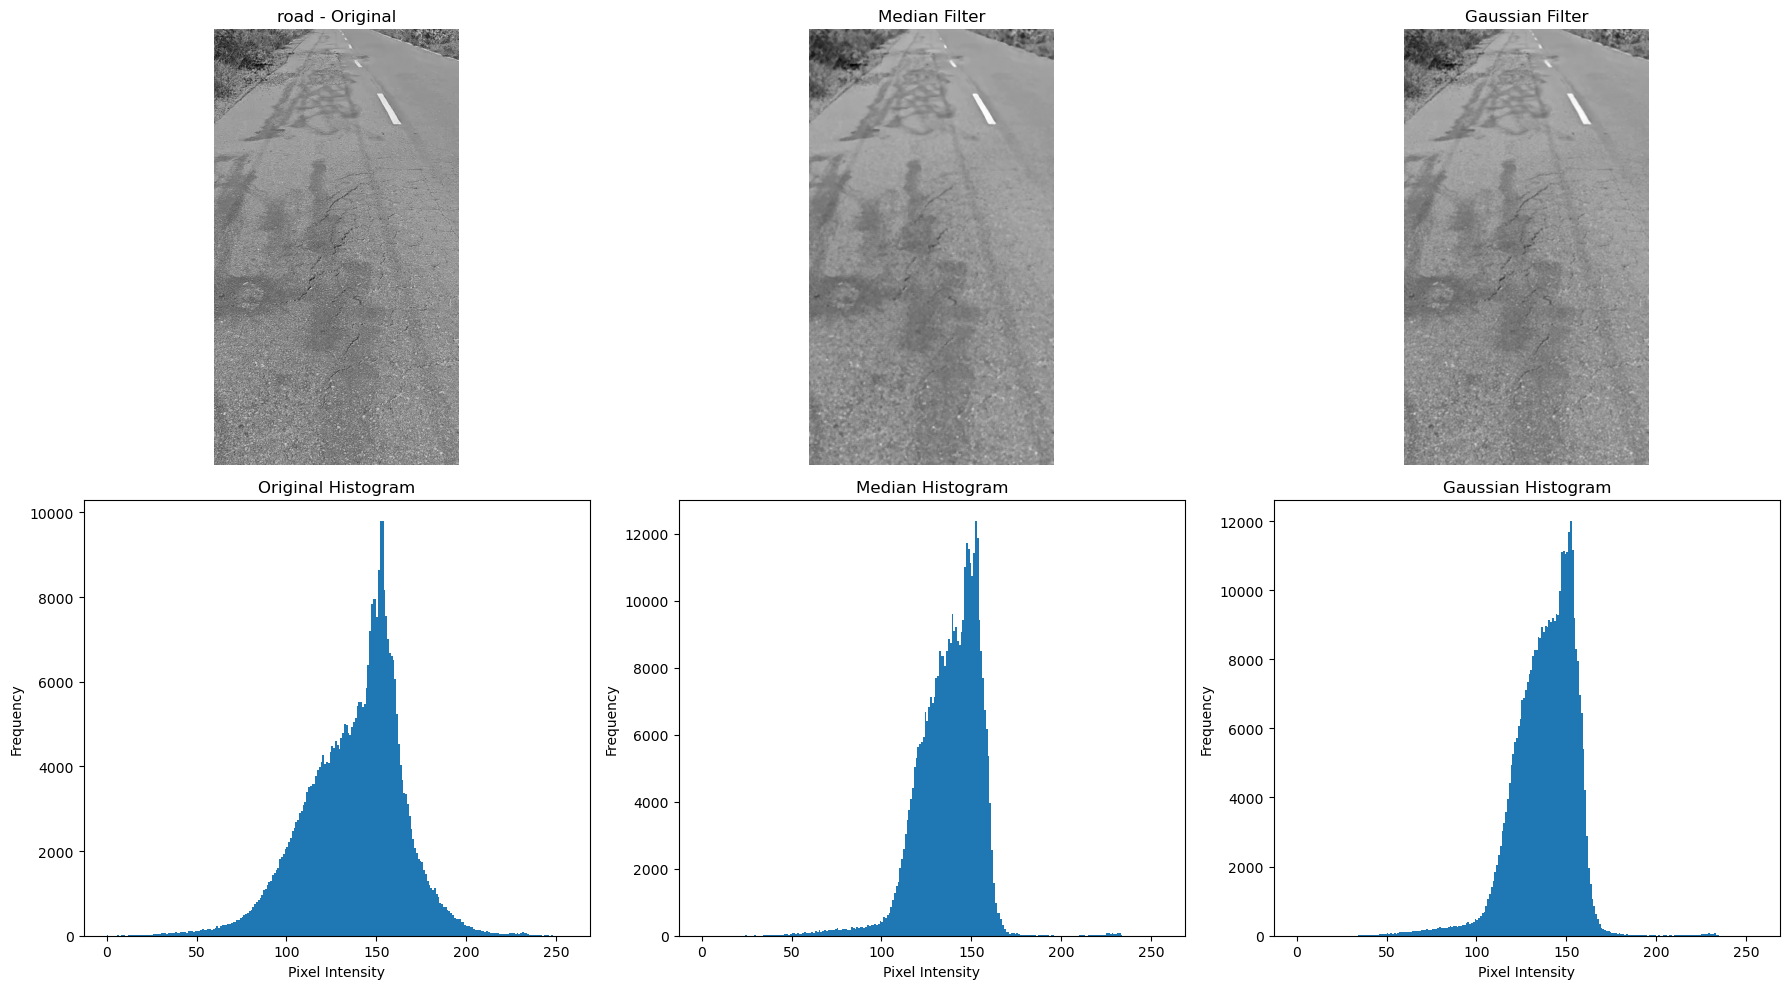

road: Frame 1 processed and saved
road: Frame 2 processed and saved
road: Frame 3 processed and saved
road: Frame 4 processed and saved
road: Frame 5 processed and saved
road: Frame 6 processed and saved
road: Frame 7 processed and saved
road: Frame 8 processed and saved
road: Frame 9 processed and saved
road: Frame 10 processed and saved
road: Frame 11 processed and saved
road: Frame 12 processed and saved
road: Frame 13 processed and saved
road: Frame 14 processed and saved
road: Frame 15 processed and saved
road: Frame 16 processed and saved
road: Frame 17 processed and saved
road: Frame 18 processed and saved
road: Frame 19 processed and saved
road: Frame 20 processed and saved
road: Frame 21 processed and saved
road: Frame 22 processed and saved
road: Frame 23 processed and saved
road: Frame 24 processed and saved
road: Frame 25 processed and saved
road: Frame 26 processed and saved
road: Frame 27 processed and saved
road: Frame 28 processed and saved
road: Frame 29 processed and 

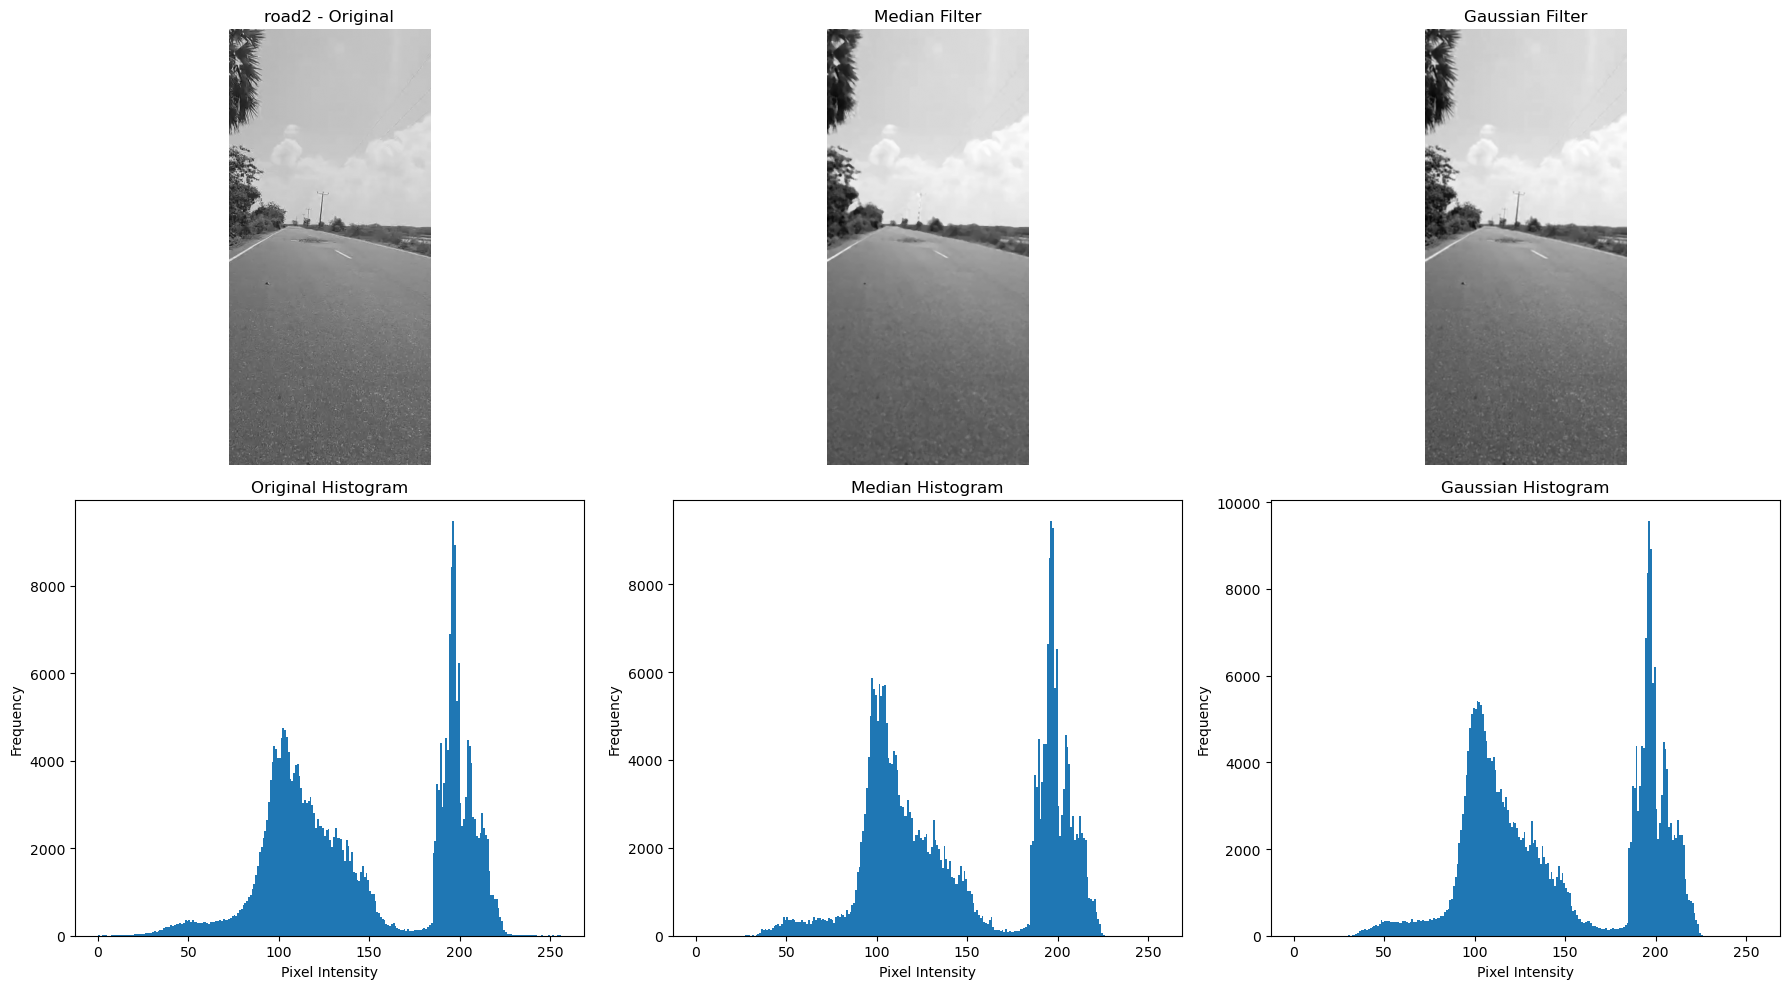

road2: Frame 1 processed and saved
road2: Frame 2 processed and saved
road2: Frame 3 processed and saved
road2: Frame 4 processed and saved
road2: Frame 5 processed and saved
road2: Frame 6 processed and saved
road2: Frame 7 processed and saved
road2: Frame 8 processed and saved
road2: Frame 9 processed and saved
road2: Frame 10 processed and saved
road2: Frame 11 processed and saved
road2: Frame 12 processed and saved
road2: Frame 13 processed and saved
road2: Frame 14 processed and saved


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# -------- SETTINGS --------
num_frames = 30
display_frame = 1   
videos = ["road", "road2"]   

for video in videos:

    # -------- INPUT FOLDER --------
    frames_folder = f"{video}_grayscale_frames"

    # -------- OUTPUT FOLDERS --------
    median_folder = f"{video}_member1_median"
    gaussian_folder = f"{video}_member1_gaussian"
    comparison_folder = f"{video}_member1_comparisons"

    os.makedirs(median_folder, exist_ok=True)
    os.makedirs(gaussian_folder, exist_ok=True)
    os.makedirs(comparison_folder, exist_ok=True)

    print(f"\nProcessing {video}...")

    shown = False   

    for frame_number in range(1, num_frames + 1):

        # Read grayscale frame
        path = f"{frames_folder}/gray_{frame_number}.jpg"
        gray = cv2.imread(path, 0)

        if gray is None:
            print(f"Frame {frame_number} not found in {frames_folder}")
            continue

        # -------- APPLY FILTERS --------
        median_img = cv2.medianBlur(gray, 5)
        gaussian_img = cv2.GaussianBlur(gray, (5, 5), 0)

        # -------- SAVE FILTERED IMAGES --------
        cv2.imwrite(f"{median_folder}/frame_{frame_number}.jpg", median_img)
        cv2.imwrite(f"{gaussian_folder}/frame_{frame_number}.jpg", gaussian_img)

        # -------- CREATE AND SAVE COMPARISON FIGURE --------
        plt.figure(figsize=(18, 10))

        # Original Image
        plt.subplot(2, 3, 1)
        plt.imshow(gray, cmap='gray')
        plt.title(f"{video} - Original")
        plt.axis('off')

        # Median Filtered Image
        plt.subplot(2, 3, 2)
        plt.imshow(median_img, cmap='gray')
        plt.title("Median Filter")
        plt.axis('off')

        # Gaussian Filtered Image
        plt.subplot(2, 3, 3)
        plt.imshow(gaussian_img, cmap='gray')
        plt.title("Gaussian Filter")
        plt.axis('off')

        # Original Histogram
        plt.subplot(2, 3, 4)
        plt.hist(gray.ravel(), bins=256, range=[0, 256])
        plt.title("Original Histogram")
        plt.xlabel("Pixel Intensity")
        plt.ylabel("Frequency")

        # Median Histogram
        plt.subplot(2, 3, 5)
        plt.hist(median_img.ravel(), bins=256, range=[0, 256])
        plt.title("Median Histogram")
        plt.xlabel("Pixel Intensity")
        plt.ylabel("Frequency")

        # Gaussian Histogram
        plt.subplot(2, 3, 6)
        plt.hist(gaussian_img.ravel(), bins=256, range=[0, 256])
        plt.title("Gaussian Histogram")
        plt.xlabel("Pixel Intensity")
        plt.ylabel("Frequency")

        plt.tight_layout()
        plt.savefig(f"{comparison_folder}/comparison_frame_{frame_number}.png")

        # -------- SHOW ONLY ONE FRAME IN NOTEBOOK --------
        if frame_number == display_frame and not shown:
            plt.show()
            shown = True
        else:
            plt.close()

        print(f"{video}: Frame {frame_number} processed and saved")

print("\nAll frames processed successfully.")